In [10]:
pip install numpy pandas matplotlib seaborn scikit-learn scipy jupyter

Note: you may need to restart the kernel to use updated packages.


In [3]:
conda install numpy pandas matplotlib seaborn scikit-learn scipy jupyter

Jupyter detected...
3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

from scipy import stats

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# ===============================
# Import Required Libraries
# ===============================

# Numerical computing
import numpy as np

# Data manipulation
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
# Machine Learning utilities
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Regression algorithms
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Model evaluation metrics
from sklearn.metrics import (
mean_squared_error,
mean_absolute_error,
r2_score
)

# Statistical analysis
from scipy import stats

# Ignore warning messages
import warnings
warnings.filterwarnings("ignore")

In [4]:
# ============================================
# Load California Housing Dataset
# ============================================

try:

 url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"

 df = pd.read_csv(url)
 print("Dataset loaded successfully from URL!")

except:

 print("URL download failed.")
 print("Generating synthetic dataset...")

np.random.seed(42)

n_samples = 20640

df = pd.DataFrame({
"longitude": np.random.uniform(-124.5, -114.5, n_samples),

"latitude": np.random.uniform(32.5, 42.0, n_samples),

"housing_median_age":
np.random.randint(1, 52, n_samples),

"total_rooms":
np.random.normal(2000, 1000, n_samples).astype(int),
"total_bedrooms":
np.random.normal(500, 250, n_samples).astype(int),

"population":
np.random.normal(1200, 800, n_samples).astype(int),

"households":
np.random.normal(450, 250, n_samples).astype(int),

"median_income":
np.random.uniform(0.5, 15, n_samples),

"median_house_value":
np.random.normal(200000, 80000, n_samples).astype(int),

"ocean_proximity":
np.random.choice(
[
"NEAR BAY",
"<1H OCEAN",
"INLAND",
"NEAR OCEAN",
"ISLAND"
],
n_samples,
p=[0.30, 0.30, 0.30, 0.09, 0.01]
)

})

# Create a relationship between features and house price
df["median_house_value"] = (

df["median_income"] * 40000 +

df["housing_median_age"] * 1000 +
df["total_rooms"] * 20 +

np.random.normal(0, 30000, n_samples)

).astype(int)

# Limit house values to realistic values
df["median_house_value"] = df["median_house_value"].clip(
lower=50000,
upper=500001
)

print("Synthetic dataset created successfully!")

Dataset loaded successfully from URL!
Synthetic dataset created successfully!


In [5]:
print(f"Dataset Shape: {df.shape}")

Dataset Shape: (20640, 10)


In [6]:
print("Statistical Summary")
print("-" * 50)

df.describe()

Statistical Summary
--------------------------------------------------


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.504529,37.244290,25.993702,2000.271657,499.451260,1193.097481,452.097190,7.748323,351189.557897
std,2.884150,2.738002,14.653187,1007.404378,250.927208,799.389974,248.636702,4.165674,139460.481209
min,-124.499884,32.500053,1.000000,-1944.000000,-478.000000,-1733.000000,-513.000000,0.500069,50000.000000
25%,-121.995208,34.876425,13.000000,1322.000000,330.000000,659.000000,286.000000,4.183671,232931.000000
50%,-119.508762,37.256805,26.000000,2003.000000,502.000000,1198.000000,451.000000,7.734265,375019.500000
75%,-117.004585,39.597604,39.000000,2676.000000,669.000000,1736.000000,616.000000,11.302962,500001.000000
max,-114.500752,41.999059,51.000000,5856.000000,1525.000000,4955.000000,1430.000000,14.999753,500001.000000


In [7]:
print("Missing Values")
print("-" * 50)

print(df.isnull().sum())

Missing Values
--------------------------------------------------
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [8]:
print("First Five Rows:")
df.head()

First Five Rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-120.754599,35.674747,35,1753,544,1195,339,3.000031,166900,<1H OCEAN
1,-114.992857,35.834057,15,3048,667,1583,655,14.078823,500001,<1H OCEAN
2,-117.180061,32.990224,40,3180,552,-448,385,0.788253,162025,INLAND
3,-118.513415,33.631396,30,-666,204,660,441,3.302429,132465,<1H OCEAN
4,-122.939814,34.335070,2,3518,8,1217,291,7.599311,427289,<1H OCEAN


In [9]:
print("Dataset Information")
print("-" * 50)

df.info()

Dataset Information
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int32  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20640 non-null  int64  
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  int64  
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(3), int32(1), int64(5), object(1)
memory usage: 1.5+ MB


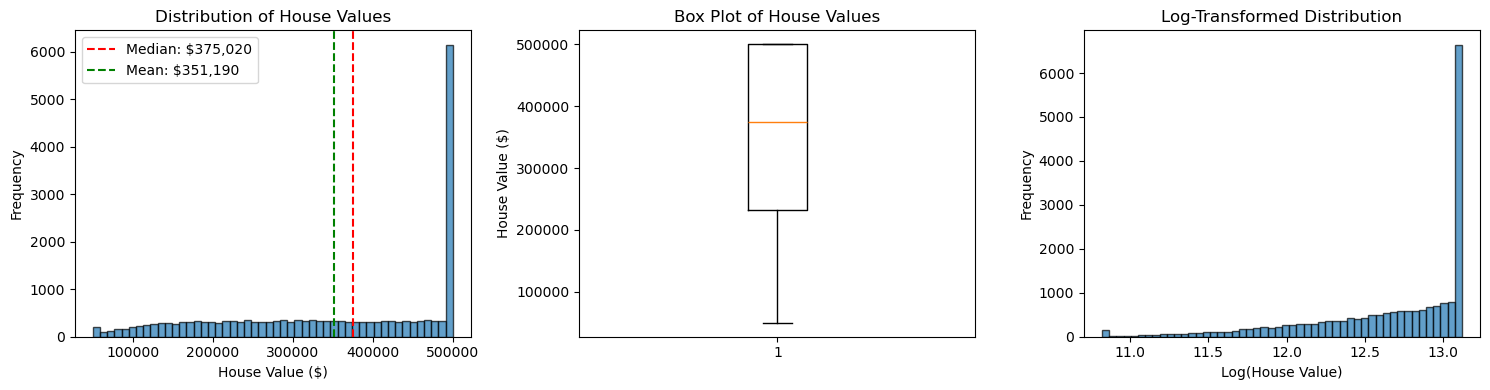

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --------------------------
# Histogram
# --------------------------

axes[0].hist(
df["median_house_value"],
bins=50,
edgecolor="black",
alpha=0.7
)

axes[0].set_title("Distribution of House Values")
axes[0].set_xlabel("House Value ($)")
axes[0].set_ylabel("Frequency")
axes[0].axvline(
df["median_house_value"].median(),
color="red",
linestyle="--",
label=f"Median: ${df['median_house_value'].median():,.0f}"
)

axes[0].axvline(
df["median_house_value"].mean(),
color="green",
linestyle="--",
label=f"Mean: ${df['median_house_value'].mean():,.0f}"
)

axes[0].legend()

# --------------------------
# Box Plot
# --------------------------

axes[1].boxplot(df["median_house_value"])

axes[1].set_title("Box Plot of House Values")
axes[1].set_ylabel("House Value ($)")

# --------------------------
# Log Transformation
# --------------------------

axes[2].hist(
np.log1p(df["median_house_value"]),
bins=50,
edgecolor="black",
alpha=0.7
)

axes[2].set_title("Log-Transformed Distribution")
axes[2].set_xlabel("Log(House Value)")
axes[2].set_ylabel("Frequency")

plt.tight_layout()

plt.show()

In [11]:
numeric_columns = df.select_dtypes(include=[np.number]).columns
correlations = (
df[numeric_columns]
.corr()["median_house_value"]
.sort_values(ascending=False)
)
print("Top Correlations with House Price")
print(correlations)

Top Correlations with House Price
median_house_value    1.000000
median_income         0.950208
total_rooms           0.111304
housing_median_age    0.077152
population            0.006149
longitude             0.004939
households            0.003198
total_bedrooms       -0.001614
latitude             -0.006360
Name: median_house_value, dtype: float64


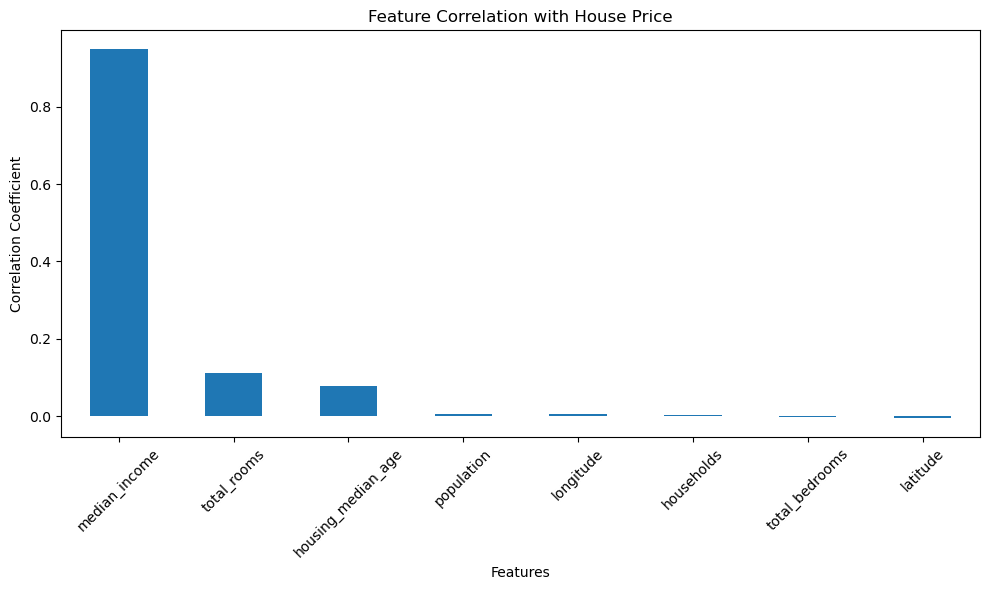

In [12]:
plt.figure(figsize=(10, 6))

correlations.drop("median_house_value").plot(kind="bar")

plt.title("Feature Correlation with House Price")

plt.xlabel("Features")

plt.ylabel("Correlation Coefficient")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

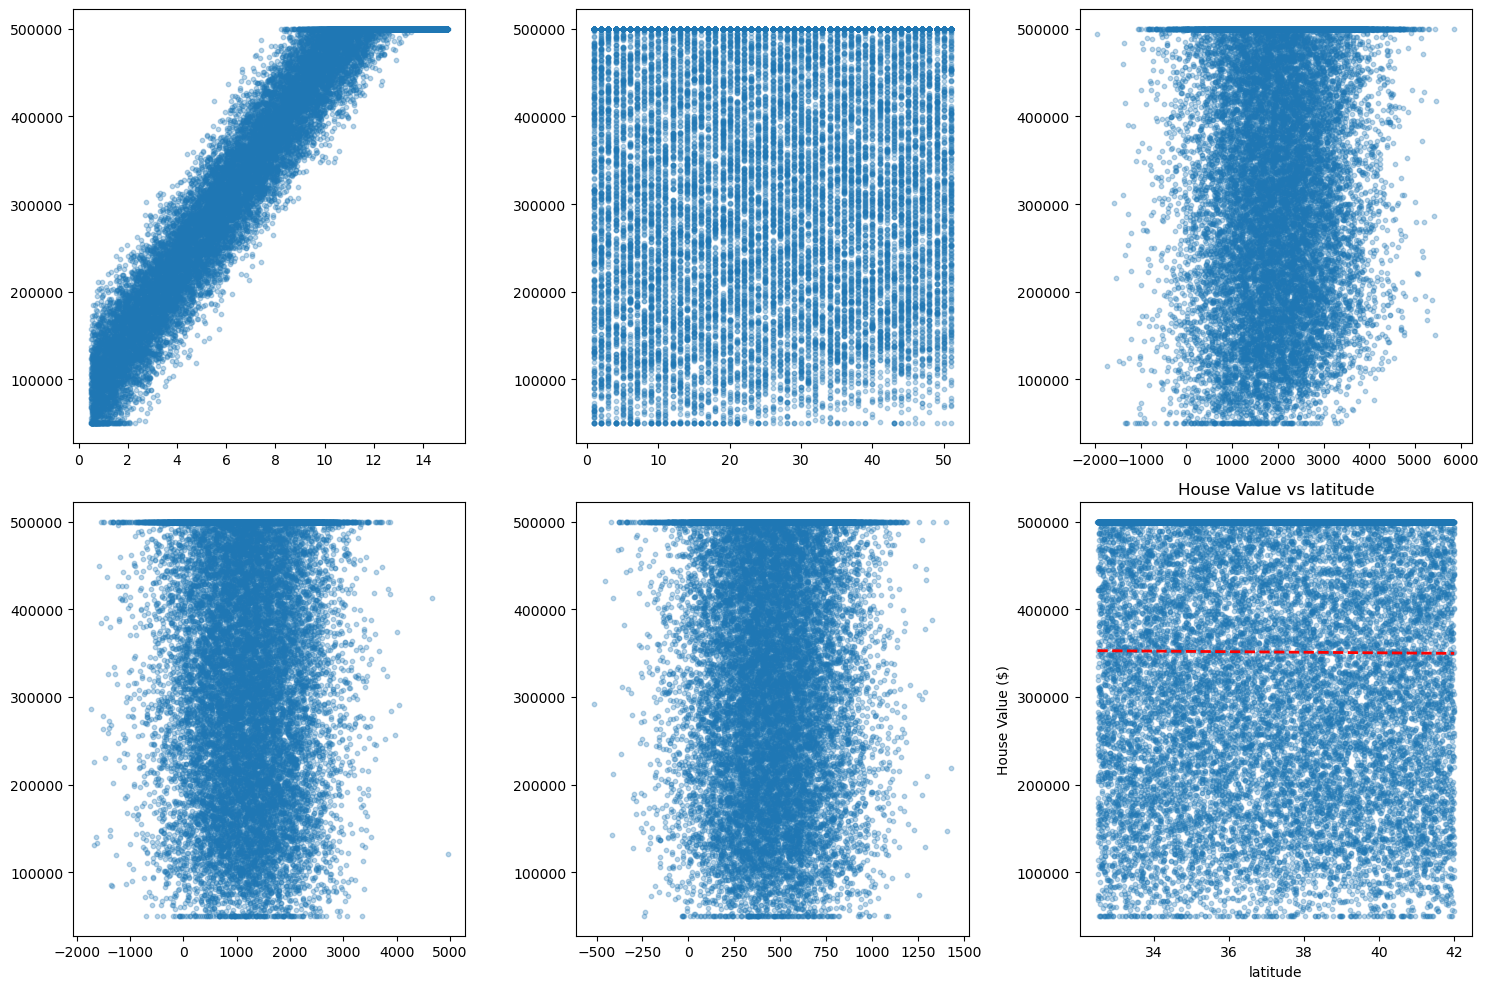

In [13]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

features = [
 "median_income",
 "housing_median_age",
 "total_rooms",
 "population",
 "households",
 "latitude"
]

for index, feature in enumerate(features):

 row = index // 3
 column = index % 3

 axes[row, column].scatter(
 df[feature],
 df["median_house_value"],
 alpha=0.3,
 s=10
)

axes[row, column].set_title(f"House Value vs {feature}")

axes[row, column].set_xlabel(feature)

axes[row, column].set_ylabel("House Value ($)")
# Add linear trend line
z = np.polyfit(df[feature], df["median_house_value"], 1)

p = np.poly1d(z)
axes[row, column].plot(
df[feature].sort_values(),
p(df[feature].sort_values()),

"r--",
linewidth=2
)

plt.tight_layout()

plt.show()

In [14]:
# Independent variable (X)
X = df[['median_income']]
# Target variable (y)
y = df['median_house_value']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [16]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
intercept = model.intercept_
coefficient = model.coef_[0]

print(f"Intercept : {intercept:.2f}")
print(f"Coefficient : {coefficient:.2f}")

Intercept : 104687.55
Coefficient : 31839.24


In [18]:
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

In [19]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

train_r2 = r2_score(y_train, train_predictions)
test_r2 = r2_score(y_test, test_predictions)

print(train_rmse)
print(test_rmse)

print(train_r2)
print(test_r2)

43430.96798961968
43564.175308646445
0.9027856362008196
0.903313534288902


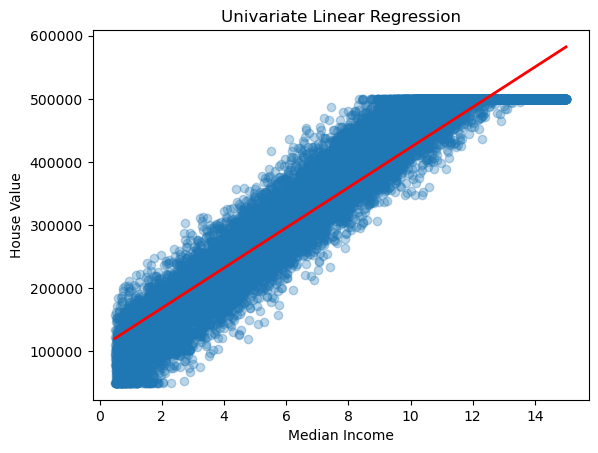

In [20]:
plt.scatter(X_train, y_train, alpha=0.3)

X_sorted = X_train.sort_values("median_income")
y_sorted = model.predict(X_sorted)

plt.plot(
X_sorted,
y_sorted,
color="red",
linewidth=2
)

plt.xlabel("Median Income")
plt.ylabel("House Value")
plt.title("Univariate Linear Regression")
plt.show()

multi variate

In [21]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()

df["ocean_proximity_encoded"] = encoder.fit_transform(
df["ocean_proximity"]
)

In [22]:
features = [
"median_income",
"housing_median_age",
"total_rooms",
"total_bedrooms",
"population",
"households",
"latitude",
"longitude",
"ocean_proximity_encoded"
]

X = df[features]
y = df["median_house_value"]

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.20,
random_state=42
)

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [26]:
coefficients = pd.DataFrame({
"Feature": features,
"Coefficient": model.coef_
})

coefficients["Absolute"] = coefficients["Coefficient"].abs()

coefficients.sort_values(
"Absolute",
ascending=False,
inplace=True
)

print(coefficients)

                   Feature    Coefficient       Absolute
0            median_income  132075.722006  132075.722006
2              total_rooms   14032.398538   14032.398538
1       housing_median_age   10254.596595   10254.596595
6                 latitude    -446.658542     446.658542
7                longitude    -281.600997     281.600997
8  ocean_proximity_encoded     263.010370     263.010370
3           total_bedrooms    -161.782602     161.782602
4               population     -80.523053      80.523053
5               households      52.724026      52.724026


In [27]:
train_predictions = model.predict(X_train)

test_predictions = model.predict(X_test)

In [31]:
train_rmse = np.sqrt(
mean_squared_error(y_train, train_predictions)
)

test_rmse = np.sqrt(
mean_squared_error(y_test, test_predictions)
)

train_r2 = r2_score(y_train, train_predictions)

test_r2 = r2_score(y_test, test_predictions)
print (train_rmse)
print (test_rmse)
print (train_r2)
print (test_r2)

39850.54330581457
40189.94506059152
0.9181535374253781
0.917711050867634
